In [1]:
# ---------- Step 0: Imports, config, data load, and shared helper functions ----------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, log_loss

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

In [2]:
# path to the raw survey data, and where the trained model will be saved
CSV_PATH = "../data/mxmh_survey_results.csv"
OUTPUT_PATH = "music_genre_model.joblib"

# mental-health score columns used as predictors
CANDIDATE_FEATURES = ["Anxiety", "Depression", "Insomnia", "OCD"]

# load the raw survey data
df = pd.read_csv(CSV_PATH)

## copied from claude
def preprocess(df):
    """Build a clean numeric feature table from the raw survey columns."""
    feat_df = pd.DataFrame(index=df.index)
    feature_cols = {}
    numeric = ["Anxiety", "Depression", "Insomnia", "OCD", "Age", "Hours per day", "BPM"]
    binary = ["While working", "Instrumentalist", "Composer", "Exploratory", "Foreign languages"]

    for col in numeric:
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors="coerce")
            if col == "BPM":
                vals = vals.where(vals.between(40, 220))
            feat_df[col] = vals
            feature_cols[col] = [col]

    for col in binary:
        if col in df.columns:
            feat_df[col] = df[col].map({"Yes": 1, "No": 0})
            feature_cols[col] = [col]

    if "Primary streaming service" in df.columns:
        service = df["Primary streaming service"].fillna("Missing").astype(str)
        dummies = pd.get_dummies(service, prefix="service")
        feat_df = pd.concat([feat_df, dummies], axis=1)
        feature_cols["Primary streaming service"] = list(dummies.columns)

    feat_df = feat_df.fillna(feat_df.median(numeric_only=True))
    return feat_df, feature_cols


def build_matrix(feat_df, feature_cols, chosen):
    """Select and stack the chosen feature columns into a numpy matrix."""
    cols = [c for feat in chosen for c in feature_cols[feat]]
    return feat_df[cols].values, cols


def cluster_genres(genre_matrix, k):
    """Group correlated genre columns into k clusters. Returns labels + linkage matrix."""
    corr = np.nan_to_num(np.corrcoef(genre_matrix.T))
    dist = np.clip(1 - corr, 0, None)
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    return fcluster(Z, t=k, criterion="maxclust"), Z


def build_combined_genres(genre_matrix, labels):
    """Collapse raw genre columns into one combined-genre column per cluster."""
    uniq = np.unique(labels)
    combined = np.zeros((genre_matrix.shape[0], len(uniq)))
    for idx, c in enumerate(uniq):
        cols = np.where(labels == c)[0]
        combined[:, idx] = (genre_matrix[:, cols].sum(axis=1) > 0).astype(int)
    return combined, uniq


# genre-listening-frequency columns are named like "Frequency [Rock]"
freq_cols = [c for c in df.columns if c.startswith("Frequency [")]
genre_names = [c.replace("Frequency [", "").rstrip("]") for c in freq_cols]
genre_matrix = (df[freq_cols] != "Never").astype(int).values

# build the predictor matrix once, up front -- it doesn't depend on k
feat_df, feature_cols = preprocess(df)
X, input_columns = build_matrix(feat_df, feature_cols, CANDIDATE_FEATURES)


In [3]:
# ---------- Step 1: Evaluate different numbers of combined genres (k) ----------

## copied from claude
def evaluate_k(X, Y, n_splits=5, seed=42):
    """Cross-validated mean AUC and log-loss for a given combined-genre target matrix Y."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    aucs, losses = [], []
    for train_idx, test_idx in kf.split(X):
        # scale using only the training fold's statistics
        scaler = StandardScaler().fit(X[train_idx])
        Xtr, Xte = scaler.transform(X[train_idx]), scaler.transform(X[test_idx])
        # one logistic regression per combined genre, fit independently
        model = MultiOutputClassifier(LogisticRegression(max_iter=1000))
        model.fit(Xtr, Y[train_idx])
        for j, est in enumerate(model.estimators_):
            probs = est.predict_proba(Xte)[:, 1]
            y_true = Y[test_idx, j]
            # AUC is undefined if a fold only has one class present
            if len(np.unique(y_true)) > 1:
                aucs.append(roc_auc_score(y_true, probs))
            losses.append(log_loss(y_true, probs, labels=[0, 1]))
    return np.mean(aucs), np.mean(losses)


# try every k from 2 to 14 combined genres and record how well each predicts
k_range = range(2, 15)
results = []
for k in k_range:
    labels, _ = cluster_genres(genre_matrix, k)
    Y, _ = build_combined_genres(genre_matrix, labels)
    mean_auc, mean_loss = evaluate_k(X, Y)
    results.append((k, mean_auc, mean_loss))

results = np.array(results)  # columns: [k, mean AUC, mean log-loss]

# pick the k with the highest mean AUC (higher AUC = better discrimination)
best_k = int(results[np.argmax(results[:, 1]), 0])


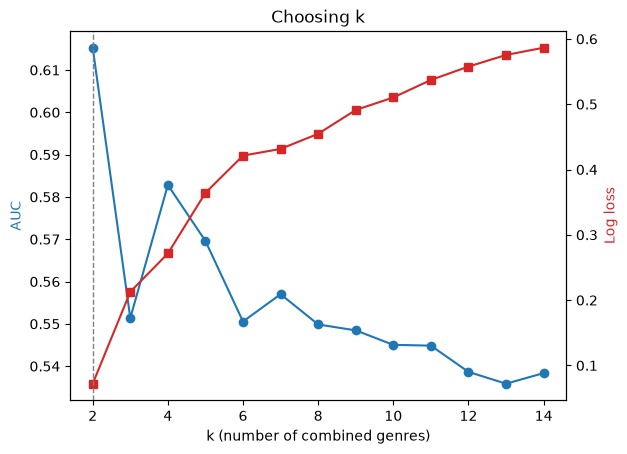

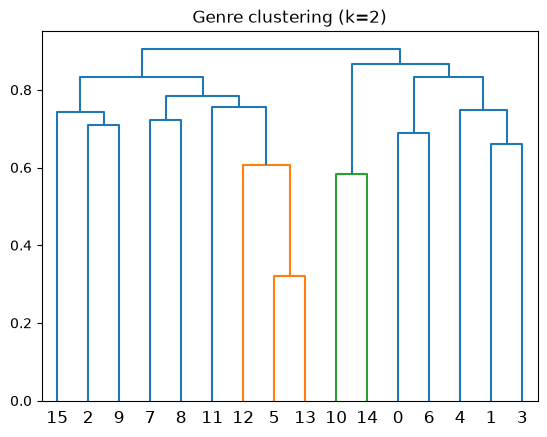

In [4]:
# ---------- Step 2: Graph the results of the k sweep ----------

# AUC (left axis) and log-loss (right axis) vs. k, to visualize the tradeoff
fig, ax1 = plt.subplots()
ax1.plot(results[:, 0], results[:, 1], "o-", color="tab:blue", label="AUC")
ax1.set_xlabel("k (number of combined genres)")
ax1.set_ylabel("AUC", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(results[:, 0], results[:, 2], "s-", color="tab:red", label="Log loss")
ax2.set_ylabel("Log loss", color="tab:red")

plt.axvline(best_k, color="gray", linestyle="--", linewidth=1, label=f"chosen k={best_k}")
plt.title("Choosing k")
plt.show()

# dendrogram showing how genres were grouped together at the chosen k
_, Z = cluster_genres(genre_matrix, best_k)
plt.figure()
dendrogram(Z)
plt.title(f"Genre clustering (k={best_k})")
plt.show()


In [5]:
# ---------- Step 3: Train the final model using the chosen k and feature set ----------

BEST_K = 13
BEST_FEATURES = CANDIDATE_FEATURES

# cluster the genres at the chosen k and build the combined-genre targets
labels, _ = cluster_genres(genre_matrix, BEST_K)
Y, cluster_ids = build_combined_genres(genre_matrix, labels)

# map each combined genre back to its original genre names, for interpretability
cluster_map = {
    f"combined_genre_{idx}": [genre_names[i] for i in np.where(labels == c)[0]]
    for idx, c in enumerate(cluster_ids)
}

# fit on the FULL dataset -- this is the final production model, not a CV run
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
model = MultiOutputClassifier(LogisticRegression(max_iter=1000))
model.fit(X_scaled, Y)

print(f"Trained model on {X_scaled.shape[0]} samples with {BEST_K} combined genres.")


Trained model on 736 samples with 13 combined genres.


In [6]:
# ---------- Step 4: Export the trained model ----------

# bundle everything needed to reproduce predictions later: the model, the
# scaler, the exact feature/column order, and human-readable genre labels
bundle = {
    "model": model,
    "scaler": scaler,
    "input_features": BEST_FEATURES,   # order matters at predict time
    "input_columns": input_columns,    # expanded column order after one-hot
    "feature_cols": feature_cols,      # needed to re-expand one-hot features later
    "k": BEST_K,
    "cluster_map": cluster_map,        # combined_genre_i -> [original genres]
}
joblib.dump(bundle, OUTPUT_PATH)

print(f"Saved model bundle to {OUTPUT_PATH}")
print("\nCombined genres:")
for name, members in cluster_map.items():
    print(f"  {name}: {members}")


Saved model bundle to music_genre_model.joblib

Combined genres:
  combined_genre_0: ['EDM']
  combined_genre_1: ['Lofi']
  combined_genre_2: ['Video game music']
  combined_genre_3: ['K pop']
  combined_genre_4: ['Latin']
  combined_genre_5: ['Hip hop', 'R&B', 'Rap']
  combined_genre_6: ['Pop']
  combined_genre_7: ['Metal', 'Rock']
  combined_genre_8: ['Classical']
  combined_genre_9: ['Jazz']
  combined_genre_10: ['Country']
  combined_genre_11: ['Folk']
  combined_genre_12: ['Gospel']


## Gen AI used for graphing and creating functions